# Clean model: trained only on `train.csv`

The best leaderboard files (v7, v8, v9) use the test file in four ways. None of them uses test **answers**, which we never had, but they do use test **inputs** and leaderboard scores:

| Step | Best files (v7–v9) | This clean model |
|---|---|---|
| Imputers that fill blanks learn from | train + test inputs | **train inputs only** |
| Training rows weighted toward | the test set's building/event mix | **no weighting** |
| Extra training copies with blanks | blank patterns copied from test rows | **generic random blanks (10% of values)** |
| Blend weight chosen by | leaderboard scores | **5-fold cross-validation on train** |

`test.csv` is read only at the very end, to make predictions. Expect a leaderboard score somewhat worse than 3.27, because some of the test-aware steps seemed to help. In exchange, the model can't have overfitted the leaderboard, and its score should hold up on unseen data.

All code is in `clean_model.py`; this notebook runs it step by step.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import clean_model as C

train = pd.read_csv(C.ROOT / 'train.csv')
print(f'train.csv: {len(train):,} rows (the only data used for fitting and choosing settings)')

Matplotlib is building the font cache; this may take a moment.


train.csv: 8,000 rows (the only data used for fitting and choosing settings)


## The two ingredients

**A. Pattern models + v3 (the v4 recipe, without test weighting).** One Ridge regression per combination of available inputs, so a row missing `previous_usage` is predicted from what it has, plus a small tree correction. This is blended 75/25 with the v3 notebook model, whose MissForest imputer is fitted on training rows only. The only change from v4: training rows are no longer weighted toward the test set's mix.

**B. LightGBM-imputed model (the v5 recipe, train only).** Four LightGBM models learn to predict each numeric input from the others, using training rows only. Extra copies of the training rows get random blanks (each value has a 10% chance), so the imputers also learn to fill several blanks at once. Blanks are then filled, and a Ridge model (v3 features plus the imputers' expected `previous_usage` and occupancy) is blended 80/20 with a gradient-boosting model.

## Choosing the blend weight by cross-validation

The training data is split into 5 parts. Each part is predicted by models trained on the other 4, so every training row gets an honest prediction from models that never saw it. Each blend weight is scored two ways: on the validation rows as they are, and with the same generic 10% random blanks (to reward models that cope with missing values). The weight with the best average of the two wins. This takes a minute or two.

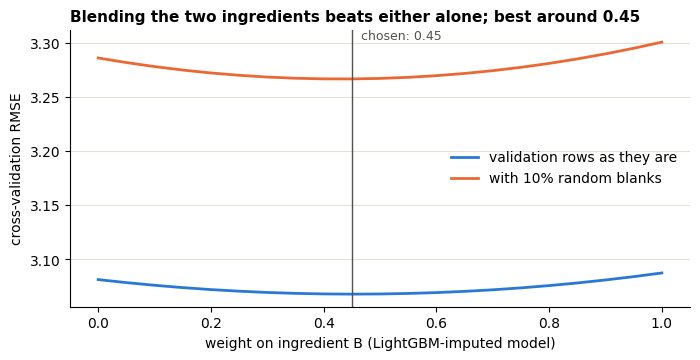

,CV RMSE,CV RMSE with random blanks,average
weight on B,,,
0.00,3.0812,3.2859,3.1836
0.20,3.0720,3.2721,3.1720
0.40,3.0680,3.2666,3.1673
0.45,3.0678,3.2666,3.1672
0.50,3.0679,3.2670,3.1675
0.60,3.0692,3.2696,3.1694
0.80,3.0757,3.2809,3.1783
1.00,3.0874,3.3005,3.1939


In [2]:
oof = C.cross_validate(train)
weight, table = C.choose_weight(train, oof)

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(table['weight on B'], table['CV RMSE'], color='#2a78d6', linewidth=2, label='validation rows as they are')
ax.plot(table['weight on B'], table['CV RMSE with random blanks'], color='#eb6834', linewidth=2, label='with 10% random blanks')
ax.axvline(weight, color='#52514e', linewidth=1)
ax.text(weight + 0.01, ax.get_ylim()[1], f' chosen: {weight:.2f}', va='top', fontsize=9, color='#52514e')
ax.set_xlabel('weight on ingredient B (LightGBM-imputed model)')
ax.set_ylabel('cross-validation RMSE')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color='#e1e0d9')
ax.legend(frameon=False)
ax.set_title('Blending the two ingredients beats either alone; best around 0.45', loc='left', fontsize=11, fontweight='bold')
plt.show()
display(table.iloc[[0, 4, 8, 9, 10, 12, 16, 20]].round(4).set_index('weight on B'))

## Final fit and predictions

Both ingredients are refitted on all 8,000 training rows and blended with the chosen weight. Only now is `test.csv` read, and only to predict.

In [3]:
test = pd.read_csv(C.ROOT / 'test.csv')
a, = C.fit_predict_A(train, [test])
b, = C.fit_predict_B(train, [test])
pred = (1 - weight) * a + weight * b

out = C.ROOT / 'candidate_clean.csv'
if out.exists():
    saved = pd.read_csv(out)
    print(f'candidate_clean.csv already exists; this run matches it to within {np.abs(saved.prediction.to_numpy() - pred).max():.6f}')
else:
    pd.DataFrame({'id': test['id'], 'prediction': pred}).to_csv(out, index=False)
    saved = pd.read_csv(out)
    print('wrote candidate_clean.csv')
print(f'rows {len(saved):,} | blanks {saved.prediction.isna().sum()} | prediction range {saved.prediction.min():.1f}-{saved.prediction.max():.1f}')
for f in ['candidate_v8.csv', 'candidate_v5_lightgbm.csv', 'candidate_v4.csv']:
    other = pd.read_csv(C.ROOT / f).prediction.to_numpy()
    print(f'RMS difference from {f}: {np.sqrt(np.mean((saved.prediction.to_numpy() - other) ** 2)):.3f}')

candidate_clean.csv already exists; this run matches it to within 0.000000
rows 3,000 | blanks 0 | prediction range 13.6-133.3
RMS difference from candidate_v8.csv: 0.712
RMS difference from candidate_v5_lightgbm.csv: 0.541
RMS difference from candidate_v4.csv: 0.467


## What to expect

- Cross-validation on train gives about **3.07** on ordinary rows and **3.27** with 10% random blanks. Test has more blanks (18% of rows) and more unusual rows than train, so its leaderboard score will be higher than 3.07.
- Compared with v8 (3.27026), this model gives up the test-aware steps. If its leaderboard score is a little worse, that difference is roughly what those steps were worth. If it's similar, the clean model is the safer final choice.
- Nothing here was tuned on the leaderboard, so its score is an honest estimate of how it would do on new data.